In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

# Задание 1

# Формулировка проблемы и KPI

**Проблема:**  
На 3-й неделе обучения наблюдается повышенный отток пользователей, что может говорить о проблемах с вовлечением, сложностью контента или снижением мотивации. Это критично, потому что ранний отток снижает LTV и эффективность привлечения пользователей.


Ключевые метрики:

- **Dropout Rate по неделям**

$$
\text{Dropout Rate}_w = \frac{D_w}{A_w}
$$

- **Retention Rate** (обратная метрика)
- **Completion Rate** (`completion_rate`)
- **Engagement Score** (`engagement_score`)
- **Среднее время в обучении** (`time_spent`)
- **Количество вопросов** (`questions_asked`)

# Задание 2

## Гипотеза 1

Я предполагаю, что на 3-й неделе увеличивается сложность материала, потому что студенты сталкиваются с более сложными темами и не справляются.  
Это повлияет на метрику *dropout rate* (увеличится) и *engagement_score* (снизится).

## Гипотеза 2

Я предполагаю, что на 3-й неделе падает мотивация студентов, потому что новизна обучения проходит, и пользователи теряют интерес.  
Это повлияет на метрики *time_spent* и *engagement_score* (снижение), а также увеличит *dropout rate*.

## Гипотеза 3

Я предполагаю, что на 3-й неделе пользователи чаще отвлекаются из-за внешних факторов (работа, учёба), потому что проходит первоначальный энтузиазм.  
Это повлияет на метрику *time_spent* (снижение) и увеличит *dropout rate*.

,hypothesis,Impact,Confidence,Ease,ICE
0,Complexity,8,7,6,336
1,Motivation,7,6,8,336
2,External factors,6,5,7,210


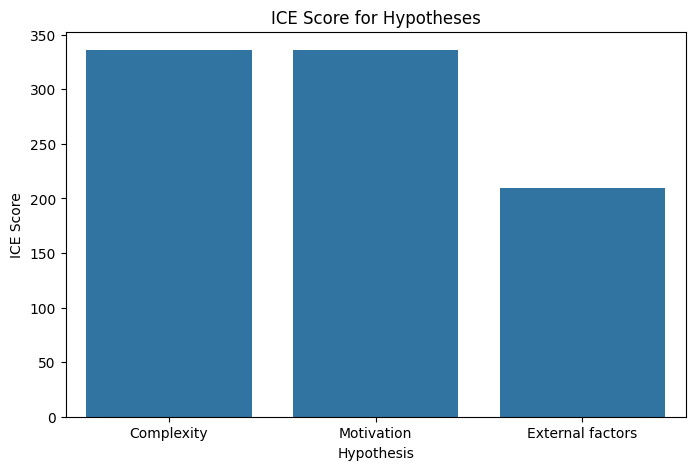

In [98]:
# Задание 3

data = pd.DataFrame({
    'hypothesis': ['Complexity', 'Motivation', 'External factors'],
    'Impact': [8, 7, 6],
    'Confidence': [7, 6, 5],
    'Ease': [6, 8, 7]
})

data['ICE'] = data['Impact'] * data['Confidence'] * data['Ease']
display(data)
plt.figure(figsize=(8, 5))
sns.barplot(x='hypothesis', y='ICE', data=data)

plt.title('ICE Score for Hypotheses')
plt.ylabel('ICE Score')
plt.xlabel('Hypothesis')

plt.show()

In [99]:
# Задание 1
df = pd.read_csv(r"learning_platform_data (1).csv")
display(df.info())
df.head()
# Вопросы:
# 1) Зависимость зарплаты от города
# 2) Какие технологии самые ценные на рынке?
# 3) Есть ли переплата за опыт?

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 60000 non-null  int64  
 1   week_number             60000 non-null  int64  
 2   employment_status       60000 non-null  object 
 3   planned_hours_per_week  60000 non-null  int64  
 4   has_mentor              60000 non-null  bool   
 5   study_group_size        60000 non-null  int64  
 6   prior_experience        60000 non-null  object 
 7   primary_device          60000 non-null  object 
 8   course_difficulty       60000 non-null  float64
 9   actual_hours_studied    58168 non-null  float64
 10  exercise_success_rate   58299 non-null  float64
 11  forum_posts             58235 non-null  float64
 12  forum_views             60000 non-null  int64  
 13  lessons_completed_pct   58187 non-null  float64
 14  dropped_out             60000 non-null

None

,user_id,week_number,employment_status,planned_hours_per_week,has_mentor,study_group_size,prior_experience,primary_device,course_difficulty,actual_hours_studied,exercise_success_rate,forum_posts,forum_views,lessons_completed_pct,dropped_out,week_start_date,is_week_3,is_working_full_time,is_beginner,has_support
0,1,1,работает полный день,20,False,3,новичок,desktop,2.1,11.9,0.92,2.0,8,100.0,False,2025-09-01,0,1,1,0
1,1,2,работает полный день,20,False,3,новичок,desktop,2.3,11.7,0.79,0.0,0,79.0,False,2025-09-08,0,1,1,0
2,1,3,работает полный день,20,False,3,новичок,desktop,8.3,1.8,0.15,0.0,0,12.0,True,2025-09-15,1,1,1,0
3,1,4,работает полный день,20,False,3,новичок,desktop,6.6,6.5,0.70,NaN,0,68.0,True,2025-09-22,0,1,1,0
4,1,5,работает полный день,20,False,3,новичок,desktop,6.2,6.9,0.58,0.0,0,48.0,True,2025-09-29,0,1,1,0


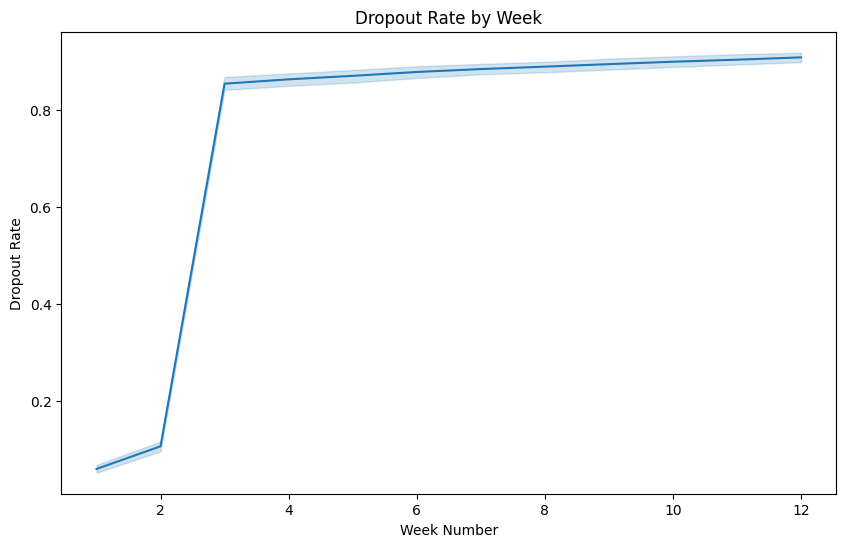

In [100]:
# Задание 4
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='week_number', y='dropped_out', estimator=lambda x: x.mean(), errorbar=('ci', 99))
plt.title('Dropout Rate by Week')
plt.ylabel('Dropout Rate')
plt.xlabel('Week Number')
plt.show()
# Пик подтверждается

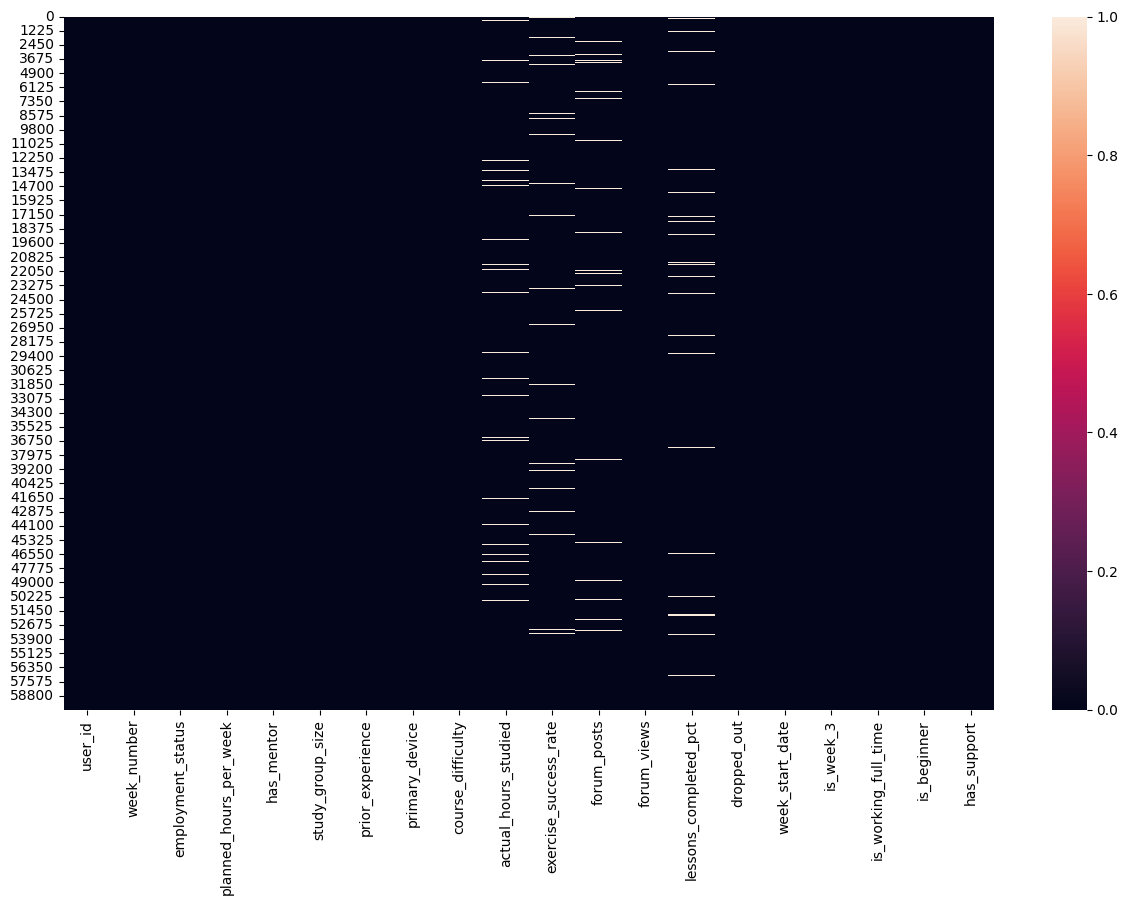

In [101]:
# Задание 5
plt.figure(figsize=(15, 9))
sns.heatmap(df.isna())
plt.show()
# Больше всего пропусков в actual_hours_studied, exercise_success_rate, forum_posts, lessons_completed_pct

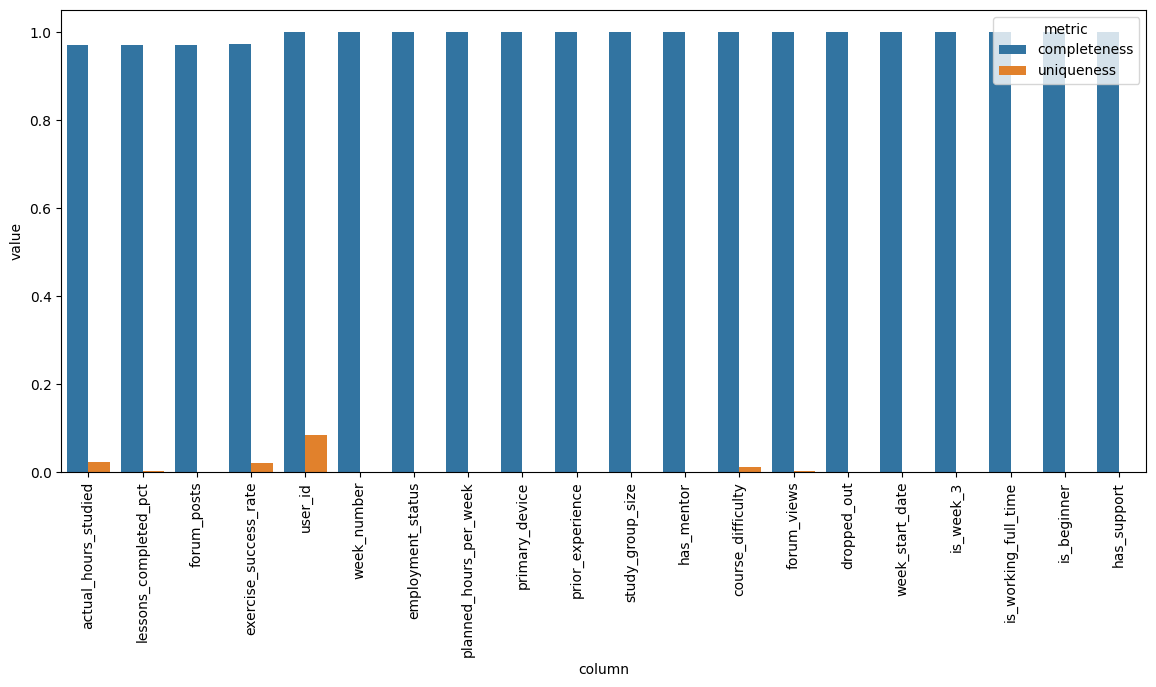

In [102]:
# Задание 6
metrics = pd.DataFrame({
    'column': df.columns,
    'completeness': 1 - df.isna().mean(),
    'uniqueness': df.nunique() / len(df)
})

metrics = metrics.sort_values(by='completeness')

metrics_melted = metrics.melt(id_vars='column', 
                              value_vars=['completeness', 'uniqueness'],
                              var_name='metric', value_name='value')

plt.figure(figsize=(14, 6))
sns.barplot(data=metrics_melted, x='column', y='value', hue='metric')
plt.xticks(rotation=90)
plt.show()
# Больше всего внимания требует колонка user_id, т.к у неё по идее должна быть uniqueness намного больше чем на графике
# и первые 4 колонки с пропусками

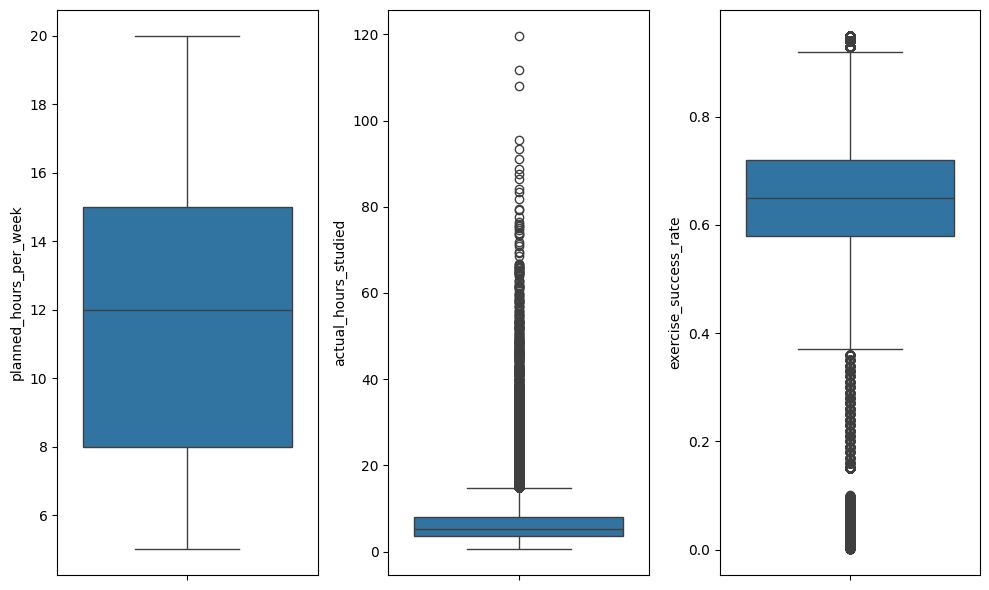

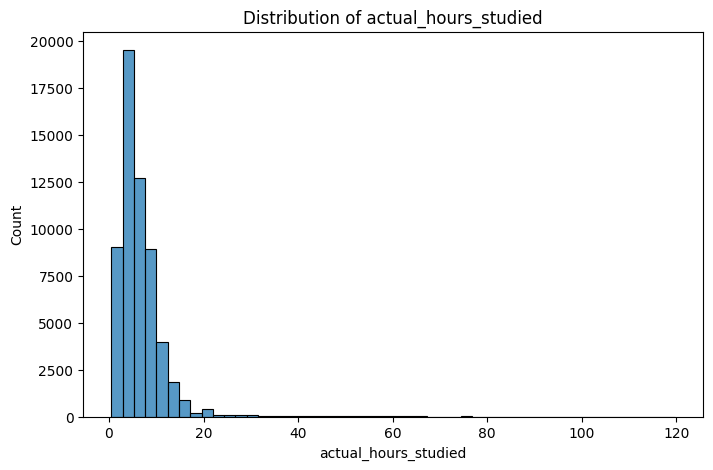

In [103]:
# Задание 7
cols = ['planned_hours_per_week', 'actual_hours_studied', 'exercise_success_rate']

plt.figure(figsize=(10, 6))

for i, col in enumerate(cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col])

plt.tight_layout()
plt.show()
# Есть выбросы у actual_hours_studied - много выбросов сверху и exercise_success_rate - много выбросов снизу
plt.figure(figsize=(8, 5))
sns.histplot(df['actual_hours_studied'], bins=50)
plt.title('Distribution of actual_hours_studied')
plt.show()
# Распределение как и ожидалось обладает положительной ассиметрией

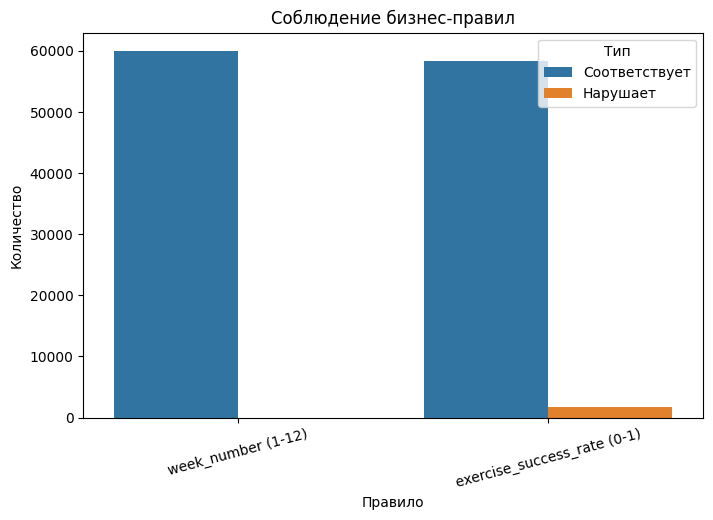

In [104]:
# Задание 8
week_rule = (df['week_number'] >= 1) & (df['week_number'] <= 12)
week_valid = week_rule.sum()
week_invalid = len(df) - week_valid

rate_rule = (df['exercise_success_rate'] >= 0) & (df['exercise_success_rate'] <= 1)
rate_valid = rate_rule.sum()
rate_invalid = len(df) - rate_valid

rule_compliance = pd.DataFrame({
    'Правило': ['week_number (1-12)', 'exercise_success_rate (0-1)'],
    'Соответствует': [week_valid, rate_valid],
    'Нарушает': [week_invalid, rate_invalid]
})

rule_compliance_melted = rule_compliance.melt(id_vars='Правило', var_name='Тип', value_name='Количество')

plt.figure(figsize=(8, 5))
sns.barplot(data=rule_compliance_melted, x='Правило', y='Количество', hue='Тип')
plt.title('Соблюдение бизнес-правил')
plt.xticks(rotation=15)
plt.show()

# Правила соблюдаются

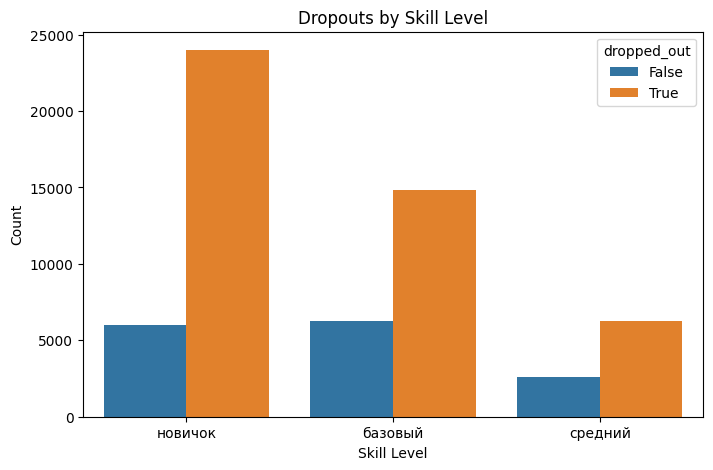

In [105]:
# Задание 9
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='prior_experience',
    hue='dropped_out'
)

plt.title('Dropouts by Skill Level')
plt.xlabel('Skill Level')
plt.ylabel('Count')

plt.show()
# Доля отчисленных выше среди новичков

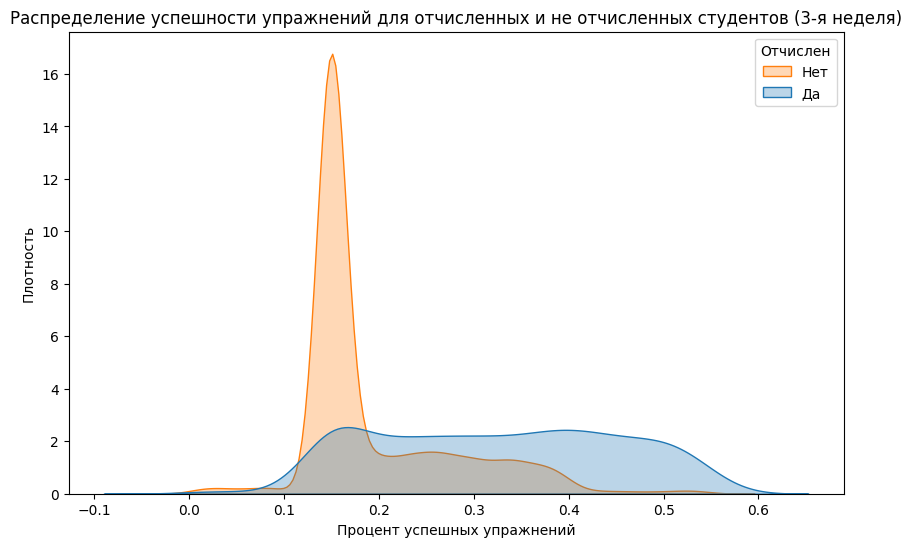

In [107]:
# Задание 10
week3_data = df[df['week_number'] == 3].dropna(subset=['exercise_success_rate'])

plt.figure(figsize=(10, 6))
sns.kdeplot(data=week3_data, x='exercise_success_rate', hue='dropped_out', common_norm=False, fill=True, alpha=0.3)
plt.title('Распределение успешности упражнений для отчисленных и не отчисленных студентов (3-я неделя)')
plt.xlabel('Процент успешных упражнений')
plt.ylabel('Плотность')
plt.legend(title='Отчислен', labels=['Нет', 'Да'])
plt.show()

# На 3-й неделе у отчисленных студентов наблюдается более низкая плотность успешности упражнений, особенно в области низких значений

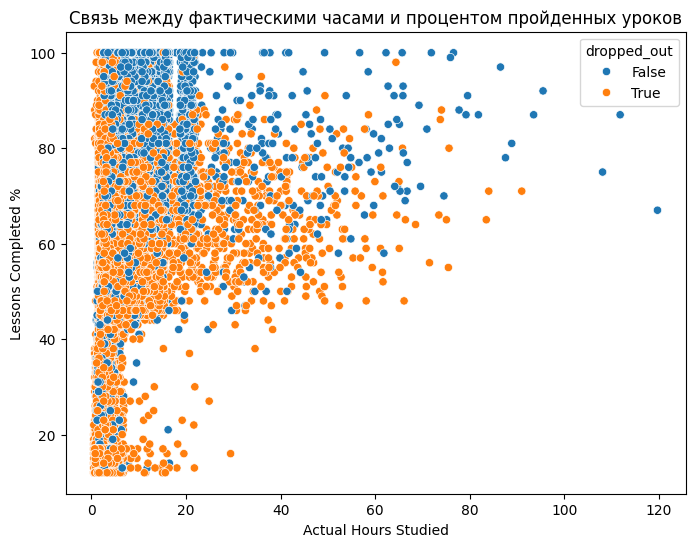

In [ ]:
# Задание 11
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='actual_hours_studied',
    y='lessons_completed_pct',
    hue='dropped_out'  # у тебя нет is_completed, используем аналог
)

plt.xlabel('Actual Hours Studied')
plt.ylabel('Lessons Completed %')
plt.title('Связь между фактическими часами и процентом пройденных уроков')
plt.show()

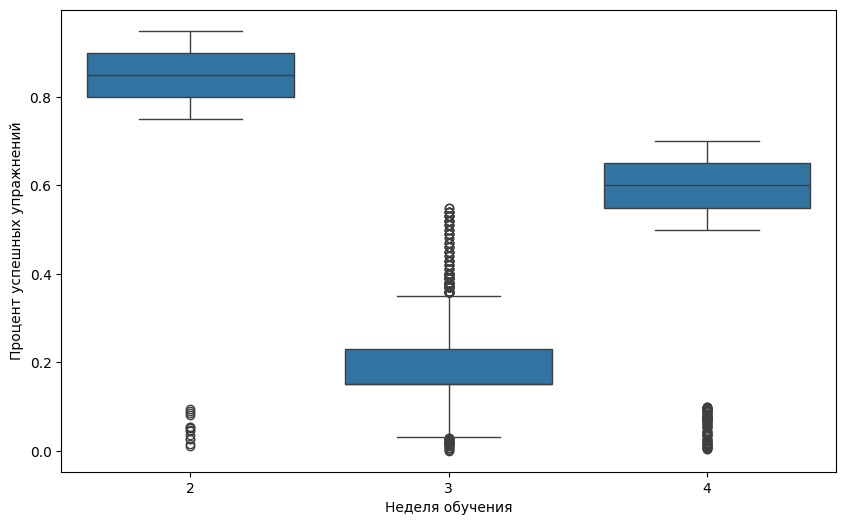

In [112]:
# Задание 12
dropped_out_students = df[df['dropped_out'] == True]
weeks_to_compare = dropped_out_students[dropped_out_students['week_number'].isin([2, 3, 4])]

plt.figure(figsize=(10, 6))
sns.boxplot(data=weeks_to_compare, x='week_number', y='exercise_success_rate')
plt.xlabel('Неделя обучения')
plt.ylabel('Процент успешных упражнений')
plt.show()

# У отчисленных студентов медианная успешность упражнений заметно падает на 3-й неделе по сравнению со 2-й

In [115]:
df.columns

Index(['user_id', 'week_number', 'employment_status', 'planned_hours_per_week',
       'has_mentor', 'study_group_size', 'prior_experience', 'primary_device',
       'course_difficulty', 'actual_hours_studied', 'exercise_success_rate',
       'forum_posts', 'forum_views', 'lessons_completed_pct', 'dropped_out',
       'week_start_date', 'is_week_3', 'is_working_full_time', 'is_beginner',
       'has_support'],
      dtype='object')

<Axes: xlabel='week_number', ylabel='dropped_out'>

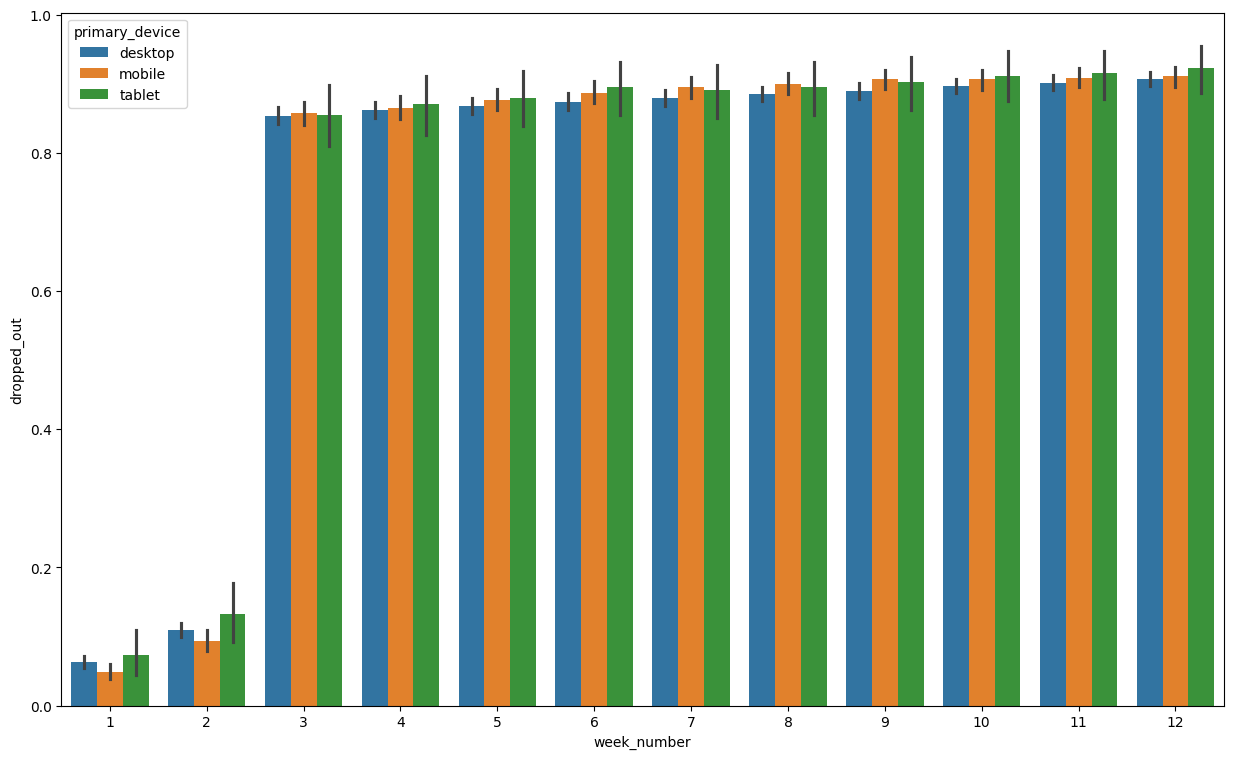

In [ ]:
plt.figure(figsize=(15,9))
sns.barplot(df, x='week_number', y='dropped_out', hue='primary_device')
# Тип устройства практически не влияет на оттток

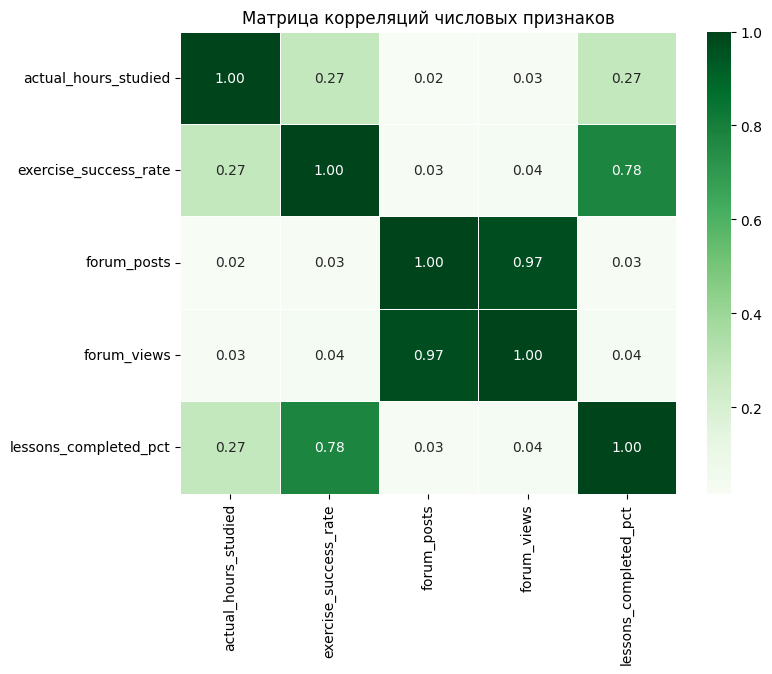

In [ ]:
# Задание 14
cols = ['actual_hours_studied', 'exercise_success_rate', 'forum_posts', 'forum_views', 'lessons_completed_pct']
corr = df[cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Greens', linewidths=0.5)
plt.title('Матрица корреляций числовых признаков')
plt.show()
# Очень коррелируют forum_posts и forum_views

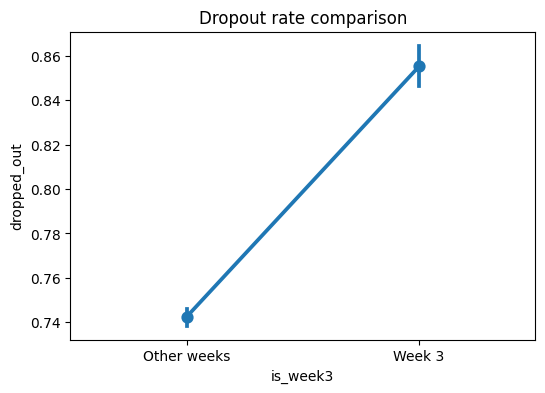

In [ ]:
# Задание 15
df['is_week3'] = df['week_number'] == 3
plt.figure(figsize=(6, 4))

sns.pointplot(
    data=df,
    x='is_week3',
    y='dropped_out',
    errorbar='ci'
)

plt.xticks([0, 1], ['Other weeks', 'Week 3'])
plt.title('Dropout rate comparison')
plt.show()
# dropout rate выше на 3-й неделе и разница похожа на статистически значимую, но без p-value нельзя утверждать это окончательно

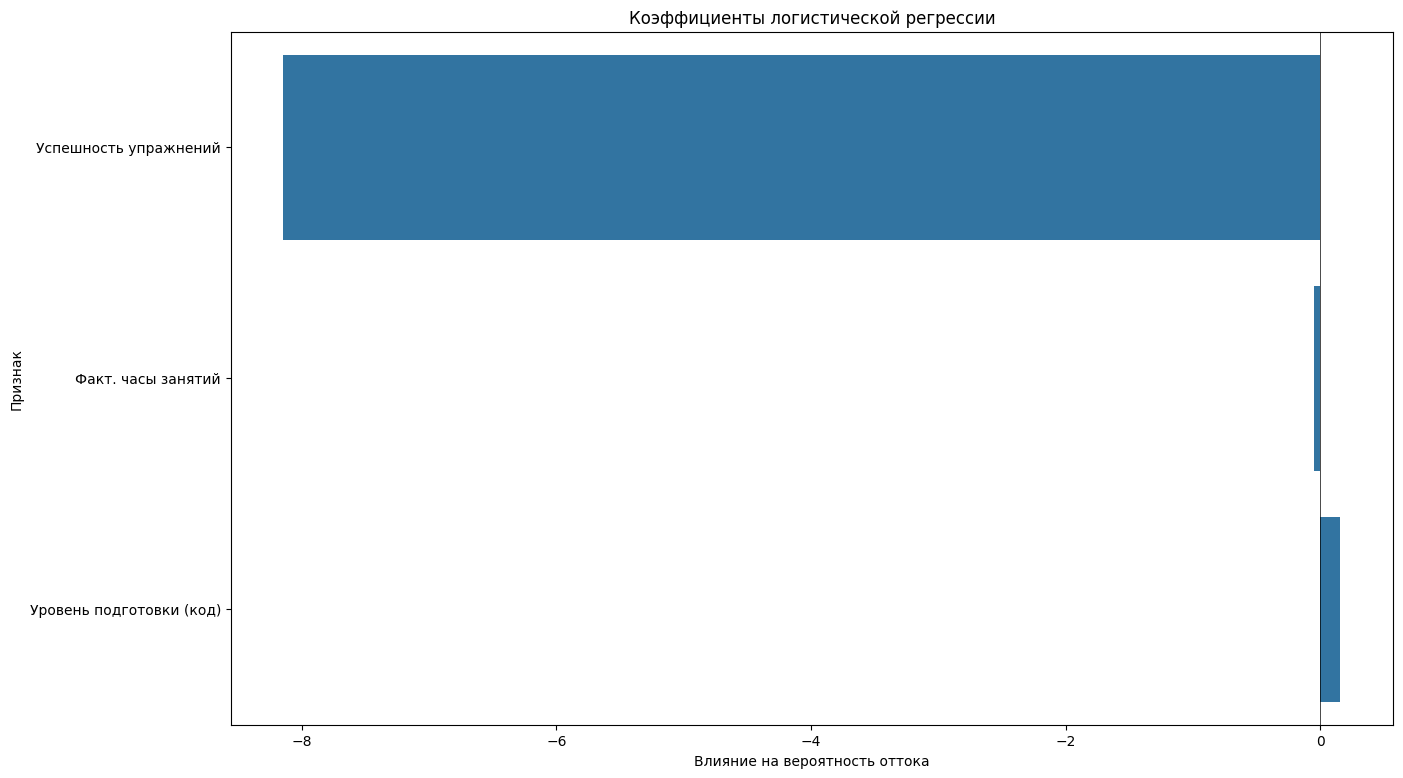

In [139]:
# Задание 16

model_df = df[['dropped_out', 'exercise_success_rate', 'actual_hours_studied', 'prior_experience']].dropna().copy()
le = LabelEncoder()
model_df['skill_level_encoded'] = le.fit_transform(model_df['prior_experience'])

X = model_df[['exercise_success_rate', 'actual_hours_studied', 'skill_level_encoded']]
y = model_df['dropped_out']

model = LogisticRegression()
model.fit(X, y)

coef_df = pd.DataFrame({
    'Признак': ['Успешность упражнений', 'Факт. часы занятий', 'Уровень подготовки (код)'],
    'Коэффициент': model.coef_[0]
})

plt.figure(figsize=(15, 9))
sns.barplot(data=coef_df, x='Коэффициент', y='Признак')
plt.title('Коэффициенты логистической регрессии')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Влияние на вероятность оттока')
plt.show()

# Низкая успешность упражнений сильнее всего увеличивает отток также влияет меньшее время и более низкий уровень подготовки.

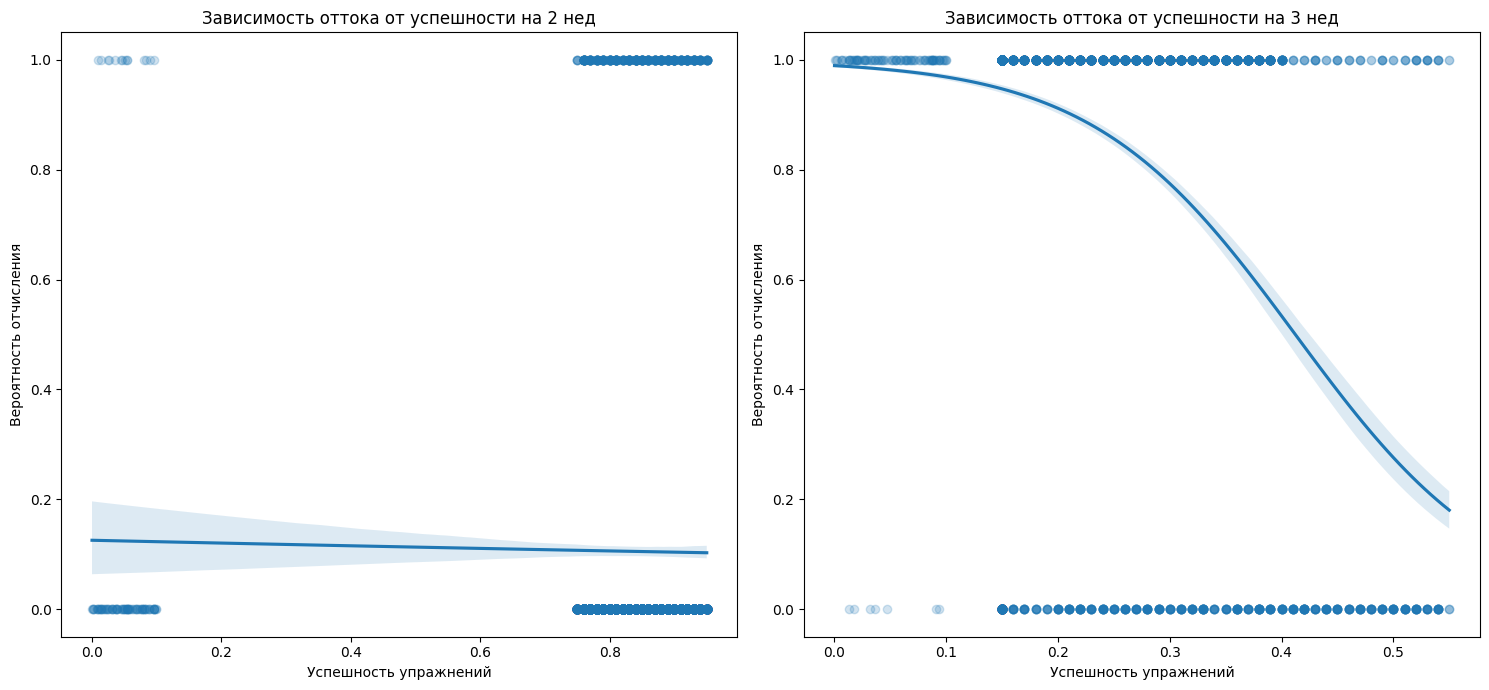

In [143]:
# Задание 17
df_week2 = df[df['week_number'] == 2].dropna(subset=['exercise_success_rate', 'dropped_out'])
df_week3 = df[df['week_number'] == 3].dropna(subset=['exercise_success_rate', 'dropped_out'])

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

sns.regplot(data=df_week2, x='exercise_success_rate', y='dropped_out', logistic=True, ax=axes[0], scatter_kws={'alpha':0.2})
axes[0].set_title('Зависимость оттока от успешности на 2 нед')
axes[0].set_ylabel('Вероятность отчисления')
axes[0].set_xlabel('Успешность упражнений')

sns.regplot(data=df_week3, x='exercise_success_rate', y='dropped_out', logistic=True, ax=axes[1], scatter_kws={'alpha':0.2})
axes[1].set_title('Зависимость оттока от успешности на 3 нед')
axes[1].set_ylabel('Вероятность отчисления')
axes[1].set_xlabel('Успешность упражнений')

plt.tight_layout()
plt.show()

# На 3-й неделе влияние низкой успешности на отток сильнее, чем на 2-й

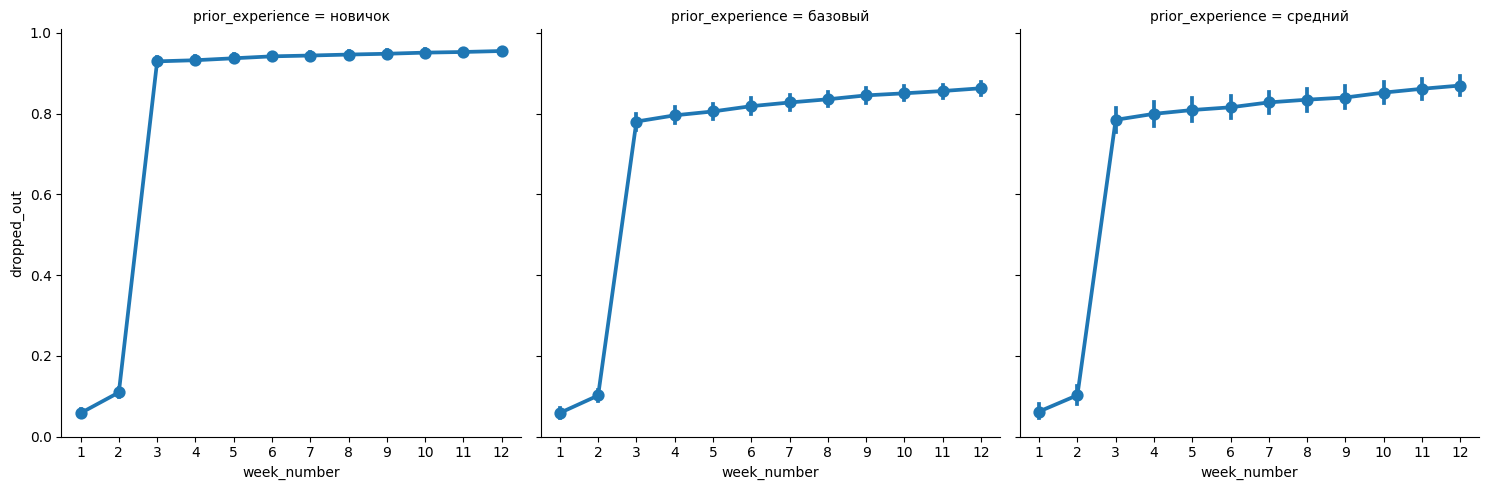

In [147]:
# Задача 18
sns.catplot(data=df, x='week_number', y='dropped_out', col='prior_experience', kind='point')
plt.show()
# гипотеза подтверждена: у новичков пик оттока на 3-й неделе наиболее выражен, у опытных — слабее.

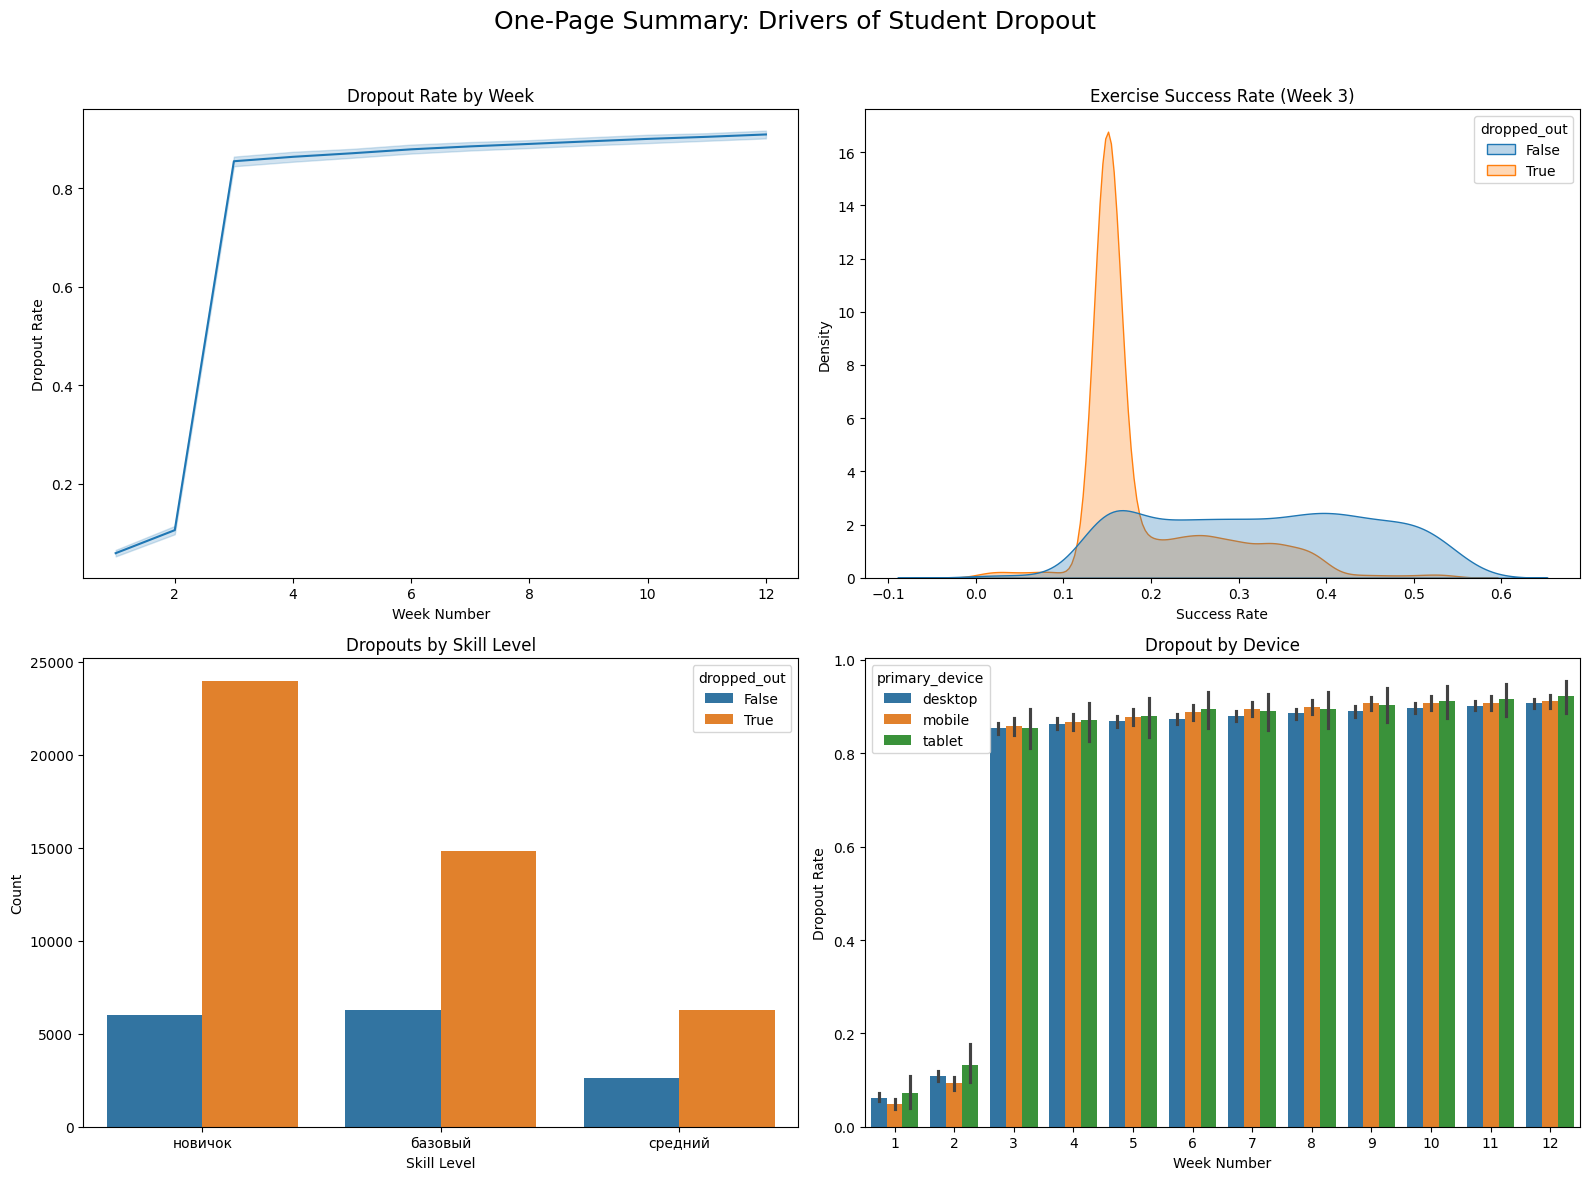

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Отток по неделям
sns.lineplot(
    data=df,
    x='week_number',
    y='dropped_out',
    estimator=lambda x: x.mean(),
    errorbar=('ci', 95),
    ax=axes[0, 0]
)
axes[0, 0].set_title('Dropout Rate by Week')
axes[0, 0].set_xlabel('Week Number')
axes[0, 0].set_ylabel('Dropout Rate')

# 2. Успешность упражнений (3-я неделя)
week3_data = df[df['week_number'] == 3].dropna(subset=['exercise_success_rate'])

sns.kdeplot(
    data=week3_data,
    x='exercise_success_rate',
    hue='dropped_out',
    common_norm=False,
    fill=True,
    alpha=0.3,
    ax=axes[0, 1]
)
axes[0, 1].set_title('Exercise Success Rate (Week 3)')
axes[0, 1].set_xlabel('Success Rate')
axes[0, 1].set_ylabel('Density')

# 3. Уровень навыков vs отток
sns.countplot(
    data=df,
    x='prior_experience',
    hue='dropped_out',
    ax=axes[1, 0]
)
axes[1, 0].set_title('Dropouts by Skill Level')
axes[1, 0].set_xlabel('Skill Level')
axes[1, 0].set_ylabel('Count')

# 4. Влияние устройства
sns.barplot(
    data=df,
    x='week_number',
    y='dropped_out',
    hue='primary_device',
    ax=axes[1, 1]
)
axes[1, 1].set_title('Dropout by Device')
axes[1, 1].set_xlabel('Week Number')
axes[1, 1].set_ylabel('Dropout Rate')

fig.suptitle('One-Page Summary: Drivers of Student Dropout', fontsize=18)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Задание 20

**Проблема:**  
Резкий рост оттока на 3-й неделе обучения.

**Обоснование:**  
График *Dropout Rate by Week* показывает локальный пик именно на 3-й неделе — это устойчивая тенденция.  
Дополнительно KDE-график показывает, что у отчислившихся студентов на этой неделе систематически ниже `exercise_success_rate`.

**Решение:**  
Внедрить:
- автоматические подсказки и разбор сложных заданий  
- микро-обучение (короткие повторения перед заданиями)  
- триггерные уведомления при падении успешности (например, < 60%)  
- персональные рекомендации на основе ошибок  

**Целевой KPI:**  
- снизить `dropout rate` на 3-й неделе на 10–20%  
- увеличить `exercise_success_rate` в этой неделе (+5–10 п.п.)  

---

## 2. Поддержка новичков (low skill users)

**Проблема:**  
Новички отчисляются чаще, чем пользователи с опытом.

**Обоснование:**  
График *Dropouts by Skill Level* показывает непропорционально большое количество отчислений среди `prior_experience = novice`, что указывает на системную проблему адаптации.

**Решение:**  
- внедрить адаптивный онбординг (пошаговый, более подробный)  
- упростить первые задания или добавить “guided mode”  
- ввести систему ранних подсказок (hints)  
- ограничить переход без достижения базового уровня успешности  

**Целевой KPI:**  
- снизить `dropout rate` среди новичков на 15–25%  
- увеличить `completion_rate` для этой группы  
- сократить `time to first success`  